In [2]:
print("Final Inspection Copilot v0.1 start")

Final Inspection Copilot v0.1 start


In [9]:
import pandas as pd

# =========================================================
# Final Inspection Bottleneck Copilot v0.1
# Step 1: Create 100% synthetic PCB lot data
# 注意：以下資料為 100% synthetic data，不使用任何公司真實資料
# =========================================================

records = [
    {
        "lot_id": "LOT-FI-001",
        "station": "Final Inspection",
        "shift": "Day",
        "input_qty": 500,
        "defect_qty": 25,
        "defect_type": "scratch",
        "delay_hours": 1.5
    },
    {
        "lot_id": "LOT-AOI-002",
        "station": "AOI",
        "shift": "Night",
        "input_qty": 800,
        "defect_qty": 56,
        "defect_type": "open",
        "delay_hours": 2.0
    },
    {
        "lot_id": "LOT-FI-003",
        "station": "Final Inspection",
        "shift": "Night",
        "input_qty": 1000,
        "defect_qty": 80,
        "defect_type": "dent",
        "delay_hours": 3.5
    },
    {
        "lot_id": "LOT-AOI-004",
        "station": "AOI",
        "shift": "Day",
        "input_qty": 600,
        "defect_qty": 18,
        "defect_type": "short",
        "delay_hours": 0.5
    },
    {
        "lot_id": "LOT-FI-005",
        "station": "Final Inspection",
        "shift": "Day",
        "input_qty": 700,
        "defect_qty": 49,
        "defect_type": "scratch",
        "delay_hours": 2.5
    }
]

# =========================================================
# Step 2: Convert list of dict into pandas DataFrame
# 小學生版：把很多張 lot 小卡片，變成一張像 Excel 的表格
# =========================================================

df = pd.DataFrame(records)

# =========================================================
# Step 3: Calculate defect_rate
# defect_rate = defect_qty / input_qty
# defect_rate_percent = defect_rate * 100
# =========================================================

df["defect_rate"] = df["defect_qty"] / df["input_qty"]
df["defect_rate_percent"] = round(df["defect_rate"] * 100, 2)

# =========================================================
# Step 4: Create report-friendly percentage label
# defect_rate_percent 是數字欄，後面分析 / groupby / 畫圖用
# defect_rate_label 是顯示欄，報告給人看用
# =========================================================

df["defect_rate_label"] = df["defect_rate_percent"].astype(str) + "%"

# =========================================================
# Step 5: Export CSV
# index=False 代表不要把 pandas 自動產生的 0,1,2,3,4 列號匯出
# =========================================================

df.to_csv("synthetic_defect_log.csv", index=False)
print("CSV exported: synthetic_defect_log.csv")

# =========================================================
# Step 6: Download CSV from Google Colab
# =========================================================

from google.colab import files

files.download("synthetic_defect_log.csv")

# =========================================================
# Step 7: Show DataFrame
# 在 Colab 裡，最後一行放 df，會漂亮顯示表格
# =========================================================

df

CSV exported: synthetic_defect_log.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,lot_id,station,shift,input_qty,defect_qty,defect_type,delay_hours,defect_rate,defect_rate_percent,defect_rate_label
0,LOT-FI-001,Final Inspection,Day,500,25,scratch,1.5,0.05,5.0,5.0%
1,LOT-AOI-002,AOI,Night,800,56,open,2.0,0.07,7.0,7.0%
2,LOT-FI-003,Final Inspection,Night,1000,80,dent,3.5,0.08,8.0,8.0%
3,LOT-AOI-004,AOI,Day,600,18,short,0.5,0.03,3.0,3.0%
4,LOT-FI-005,Final Inspection,Day,700,49,scratch,2.5,0.07,7.0,7.0%


In [10]:
# =========================================================
# Final Inspection Bottleneck Copilot v0.1
# Step 8: Station-level summary using groupby
#
# 小學生版：
# 把同一個 station 的 lot 放在一起。
# AOI 一組，Final Inspection 一組。
# 然後把 input_qty、defect_qty、delay_hours 加總。
# =========================================================

station_summary = df.groupby("station").agg({
    "input_qty": "sum",
    "defect_qty": "sum",
    "delay_hours": "sum"
}).reset_index()

# =========================================================
# Step 9: Recalculate station-level defect_rate
#
# 注意：
# 不要直接平均每筆 lot 的 defect_rate。
# station 層級應該重新計算：
# station_defect_rate = sum(defect_qty) / sum(input_qty)
# =========================================================

station_summary["defect_rate"] = station_summary["defect_qty"] / station_summary["input_qty"]
station_summary["defect_rate_percent"] = round(station_summary["defect_rate"] * 100, 2)
station_summary["defect_rate_label"] = station_summary["defect_rate_percent"].astype(str) + "%"

# =========================================================
# Step 10: Show station summary
# =========================================================

station_summary

,station,input_qty,defect_qty,delay_hours,defect_rate,defect_rate_percent,defect_rate_label
0,AOI,1400,74,2.5,0.052857,5.29,5.29%
1,Final Inspection,2200,154,7.5,0.070000,7.00,7.0%


In [11]:
station_summary.to_csv("station_summary.csv", index=False)
print("CSV exported: station_summary.csv")

from google.colab import files
files.download("station_summary.csv")

CSV exported: station_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# =========================================================
# Final Inspection Bottleneck Copilot v0.1
# Step 11: Shift-level summary using groupby
#
# 小學生版：
# 把同一個 shift 的 lot 放在一起。
# Day 一組，Night 一組。
# 然後把 input_qty、defect_qty、delay_hours 加總。
# =========================================================

shift_summary = df.groupby("shift").agg({
    "input_qty": "sum",
    "defect_qty": "sum",
    "delay_hours": "sum"
}).reset_index()

# =========================================================
# Step 12: Recalculate shift-level defect_rate
#
# 注意：
# 不要直接平均每筆 lot 的 defect_rate。
# shift 層級應該重新計算：
# shift_defect_rate = sum(defect_qty) / sum(input_qty)
# =========================================================

shift_summary["defect_rate"] = shift_summary["defect_qty"] / shift_summary["input_qty"]
shift_summary["defect_rate_percent"] = round(shift_summary["defect_rate"] * 100, 2)
shift_summary["defect_rate_label"] = shift_summary["defect_rate_percent"].astype(str) + "%"

# =========================================================
# Step 13: Show shift summary
# =========================================================

shift_summary

,shift,input_qty,defect_qty,delay_hours,defect_rate,defect_rate_percent,defect_rate_label
0,Day,1800,92,4.5,0.051111,5.11,5.11%
1,Night,1800,136,5.5,0.075556,7.56,7.56%


In [13]:
shift_summary.to_csv("shift_summary.csv", index=False)
print("CSV exported: shift_summary.csv")

from google.colab import files
files.download("shift_summary.csv")

CSV exported: shift_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

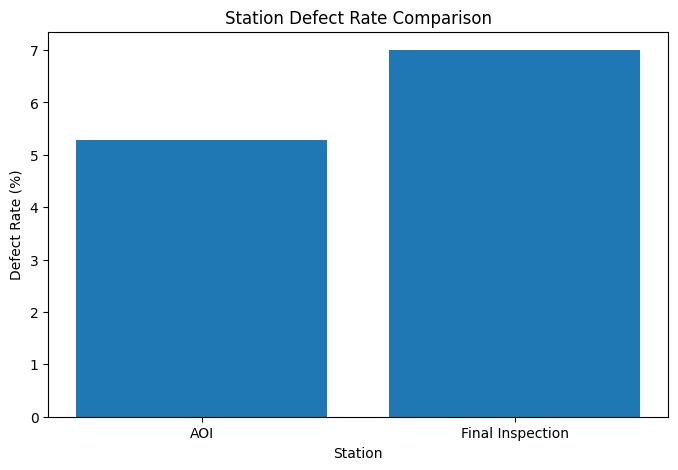

Chart exported: station_defect_rate_chart.png


In [14]:
import matplotlib.pyplot as plt

# =========================================================
# Final Inspection Bottleneck Copilot v0.1
# Step 14: Create station defect rate chart
#
# 小學生版：
# 把 AOI 和 Final Inspection 的 defect_rate 畫成長條圖，
# 讓主管一眼看出哪個 station 比較嚴重。
# =========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    station_summary["station"],
    station_summary["defect_rate_percent"]
)

plt.title("Station Defect Rate Comparison")
plt.xlabel("Station")
plt.ylabel("Defect Rate (%)")

plt.savefig("station_defect_rate_chart.png", dpi=150, bbox_inches="tight")

plt.show()

print("Chart exported: station_defect_rate_chart.png")

In [15]:
from google.colab import files

files.download("station_defect_rate_chart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>